# Notebook 02: Sequence layer, readout, and training

Notebook 01 established that the dynamics are correct. This one puts them to work: wrap the
oscillator bank in a readout, train it, and see what breaks.

Two things needed fix, both were predicted by notebook 01:

1. **Input gain.** across a 10-100 Hz bank the
   fastest units respond 100x more weakly than the slowest. With a flat `W_in` the whole
   population produces states of order $10^{-6}$, the softmax is uniform, and no gradient flows.
   Scaling each row of `W_in` by $2\zeta\omega^2$ fixes it.
2. **Pooling.** A sinusoidal response time-averages to approximately zero, so mean-pooling
   destroys exactly the signal we want. The class information is in response *power*.

**Contents**

1. The sequence model, and what sequence length costs you
2. Warm-up task: frequency discrimination
3. The two fixes, demonstrated
4. Training loop
5. Sequential MNIST, row-wise
6. Frozen vs learned $(\omega, \zeta)$
7. Sequential MNIST, pixel-wise


In [19]:
# `horn` is importable because the package is installed:  pip install -e .
# from the repo root. No sys.path surgery, and it works identically from
# JupyterLab, VS Code, a plain script, or a Colab checkout.
try:
    from horn.paths import REPO, DATA_DIR, RESULTS_DIR
except ModuleNotFoundError as exc:                     
    raise ModuleNotFoundError(
        "The `horn` package is not installed in this kernel.\n"
        "From the repo root:  pip install -e \".[dev,notebooks]\"\n"
        "then restart the kernel. Check you are on the right interpreter: "
        "the venv at .venv/bin/python, not a system Python."
    ) from exc

import time
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from horn.core import step as horn_step, init_state
from horn.model import (init_net, forward, loss_and_acc, freeze_oscillators,
                        usable_band, log_spaced_bands, band_summary, TWOPI)

plt.rcParams.update({"figure.dpi": 220, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
print("repo", REPO)
print("jax", jax.__version__, jax.devices())


repo C:\Code\HORN-JAX.dev
jax 0.11.0 [CpuDevice(id=0)]


## 1. The sequence model

A HORN layer plus a linear readout. The only real design choices are how the trajectory is
collapsed into a fixed-size vector, and what the readout reads.

**Read $(x, v/\omega)$, not $(x, v)$.** For a harmonic oscillator $v \sim \omega x$, so at 100 Hz the
raw velocity is ~600x the position. A readout given both would be dominated by velocity purely
through units. Dividing by $\omega$ puts them on the same scale; these are also the coordinates in
which $x^2 + (v/\omega)^2$ is proportional to energy.

**Time is physical.** A sequence of $L$ steps is treated as spanning a real duration, so
$dt = T_{seq}/L$ and $\omega$ stays in Hz. Everything from notebook 01 carries over.

### What sequence length costs you

Two walls, from `usable_band()`:

- **slow wall**: a unit must complete at least ~1 cycle inside the sequence, else it never
  oscillates and is just a leaky integrator. $f_{min} = 1/(L\,dt)$
- **fast wall**: integration needs ~10 samples per period. $f_{max} = 1/(10\,dt)$

Their ratio is $f_{max}/f_{min} = L/10$ — set by **sequence length alone**, independent of $dt$.

This decides whether a nested band structure is representable at all. A 1:6 theta-gamma nesting
needs $L \gtrsim 60$. Row-wise MNIST, at 28 steps, simply cannot hold it.

In [20]:
print(f"{'task':>22} {'L':>6} {'dt (s)':>9} {'f_min':>8} {'f_max':>8} {'ratio':>7}  nesting?")
for name, L, T_seq in [("MNIST row-wise", 28, 0.28),
                       ("MNIST pixel-wise", 784, 1.0),
                       ("freq. discrimination", 100, 0.1)]:
    dt = T_seq / L
    lo, hi = usable_band(L, dt)
    ok = "1:6 fits" if hi / lo >= 6 else "1:6 DOES NOT fit"
    print(f"{name:>22} {L:>6} {dt:>9.5f} {lo:>8.1f} {hi:>8.1f} {hi/lo:>7.1f}  {ok}")

                  task      L    dt (s)    f_min    f_max   ratio  nesting?
        MNIST row-wise     28   0.01000      3.6     10.0     2.8  1:6 DOES NOT fit
      MNIST pixel-wise    784   0.00128      1.0     78.4    78.4  1:6 fits
  freq. discrimination    100   0.00100     10.0    100.0    10.0  1:6 fits


## 2. Warm-up: frequency discrimination

Before MNIST, a task oscillators should be *good* at: classify which of three frequencies
(15 / 30 / 60 Hz) a noisy sinusoid carries. Random phase per example, so the answer cannot come
from a fixed time offset.

If a bank of resonators cannot do this, nothing downstream is worth debugging.

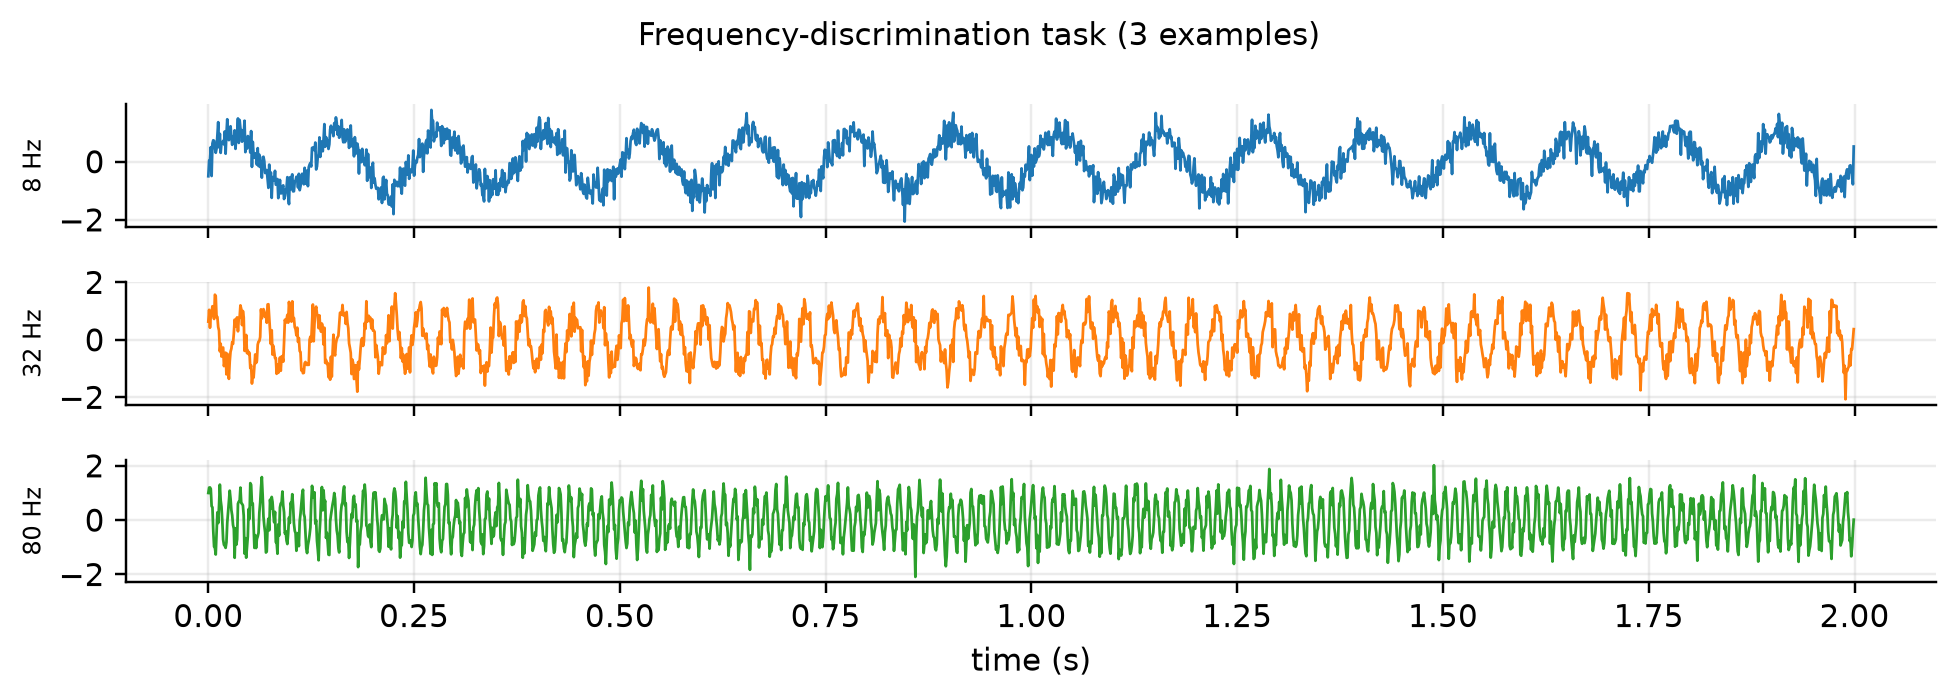

usable band 0.5-100.0 Hz; all three classes sit inside it


In [21]:
L_F, DT_F = 2000, 1e-3                   # sequence length and time step for frequency discrimination task  
F_LO, F_HI = usable_band(L_F, DT_F)      
CLASSES = jnp.array([8.0, 32.0, 80.0])     # frequencies in Hz, all inside the usable band

def freq_batch(key, n, noise=0.3):
    """Noisy sinusoid at one of CLASSES, random phase. -> (L, n, 1), (n,)"""
    k1, k2, k3 = jax.random.split(key, 3)
    y = jax.random.randint(k1, (n,), 0, len(CLASSES))
    phase = jax.random.uniform(k2, (n,)) * 2 * jnp.pi
    t = jnp.arange(1, L_F + 1) * DT_F
    f = CLASSES[y]
    x = jnp.sin(2 * jnp.pi * f[None, :] * t[:, None] + phase[None, :])
    x = x + noise * jax.random.normal(k3, (L_F, n))
    return x[..., None], y

xb_all, yb_all = freq_batch(jax.random.PRNGKey(0), 27)  # Generate enough samples to guarantee all classes
indices = jnp.array([jnp.where(yb_all == c)[0][0] for c in range(len(CLASSES))])
xb, yb = xb_all[:, indices], yb_all[indices]

fig, ax = plt.subplots(3, 1, figsize=(9, 3.2), sharex=True)
for i in range(3):
    ax[i].plot(np.arange(L_F) * DT_F, np.asarray(xb[:, i, 0]), lw=0.9, color=f"C{i}")
    ax[i].set_ylabel(f"{float(CLASSES[yb[i]]):.0f} Hz", fontsize=8)
ax[-1].set_xlabel("time (s)")
fig.suptitle("Frequency-discrimination task (3 examples)", fontsize=10)
plt.tight_layout(); plt.show()
print(f"usable band {F_LO:.1f}-{F_HI:.1f} Hz; all three classes sit inside it")

## 3. The two fixes, demonstrated

### 3a. Input gain

Build the same network twice — flat `W_in` versus `W_in` scaled by $2\zeta\omega^2$ — and look at
the magnitude of everything.

In [22]:
N_OSC = 24
f_bank = log_spaced_bands(N_OSC, F_LO, F_HI)

t = jnp.arange(1, L_F + 1) * DT_F
probe = (jnp.sin(2 * jnp.pi * 30.0 * t)[:, None, None]) * jnp.ones((1, 1, 1))
probe_y = jnp.zeros((1,), int)

print(f"{'input_gain':>12} {'mean|x|':>11} {'mean|logit|':>12} {'loss':>9} {'grad readout':>14} {'grad W_rec':>12}")
for gain in ["flat", "normalised"]:
    p = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15,
                 input_gain=gain, pool="rms")
    _, (xs, vs) = jax.lax.scan(
        lambda c, u: (lambda new, _o: (new, (new.x, new.v)))(*horn_step(p.horn, c, u, DT_F)),
        init_state(N_OSC, batch=1), probe)
    lg = forward(p, probe, DT_F, pool="rms")
    l = loss_and_acc(p, probe, probe_y, DT_F, "rms")[0]
    g = jax.grad(lambda q: loss_and_acc(q, probe, probe_y, DT_F, "rms")[0])(p)
    print(f"{gain:>12} {float(jnp.abs(xs).mean()):>11.3e} {float(jnp.abs(lg).mean()):>12.3e} "
          f"{float(l):>9.6f} {float(jnp.linalg.norm(g.readout.W)):>14.3e} "
          f"{float(jnp.linalg.norm(g.horn.W_rec)):>12.3e}")
print(f"\nln(3) = {np.log(3):.6f}  <- a loss pinned here means the softmax is uniform:")

  input_gain     mean|x|  mean|logit|      loss   grad readout   grad W_rec
        flat   9.892e-06    2.672e-05  1.098582      2.006e-04    1.584e-06
  normalised   7.943e-03    2.306e-02  1.086488      8.771e-02    3.697e-05

ln(3) = 1.098612  <- a loss pinned here means the softmax is uniform:


### 3b. Pooling

A sinusoid averages to zero over time. The longer the sequence and the higher the frequency, the
closer to zero the mean gets — so mean-pooling throws away more of the signal exactly where the
oscillator bank is working hardest.

In [ ]:
p = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15)
print(f"{'drive':>8} {'|mean(x)|':>12} {'rms(x)':>10} {'mean/rms':>10}")
for f in [8.0, 32.0, 150.0]:
    u = (jnp.sin(2 * jnp.pi * f * t)[:, None, None]) * jnp.ones((1, 1, 1))
    _, (xs, vs) = jax.lax.scan(
        lambda c, uu: (lambda new, _o: (new, (new.x, new.v)))(*horn_step(p.horn, c, uu, DT_F)),
        init_state(N_OSC, batch=1), u)
    m = float(jnp.abs(xs.mean(0)).mean()); r = float(jnp.sqrt((xs ** 2).mean(0)).mean())
    print(f"{f:>7.0f} Hz {m:>12.5f} {r:>10.5f} {m / r:>10.3f}")
print("\nThe ratio falls with frequency: mean-pooling is worst for the fastest units.")

   drive    |mean(x)|     rms(x)   mean/rms
      8 Hz      0.00020    0.01433      0.014
     32 Hz      0.00006    0.00881      0.007
    150 Hz      0.00001    0.00175      0.007

The ratio falls with frequency: mean-pooling is worst for the fastest units.


## 4. Training loop

Standard ADAM, with two things that matter for oscillators:

- **gradient clipping by global norm.** Oscillatory recurrence produces occasional very large
  gradients; without clipping a single bad batch can destroy the run.
- **$\omega$ and $\zeta$ are stored as logs**, so they cannot cross zero into negative damping no
  matter what the optimiser does. Implemented in `core.py`.

In [ ]:
def make_train_step(opt, dt, pool, freeze=False):
    """Returns a jitted update. `freeze` zeroes the gradients on log_omega/log_zeta."""
    @jax.jit
    def train_step(params, opt_state, x, y):
        (loss, acc), grads = jax.value_and_grad(
            lambda q: loss_and_acc(q, x, y, dt, pool), has_aux=True)(params)
        if freeze:
            grads = freeze_oscillators(grads)
        gnorm = optax.global_norm(grads)
        updates, opt_state = opt.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state, loss, acc, gnorm
    return train_step


def train(params, batch_fn, dt, pool, steps=400, batch=64, lr=3e-3,
          freeze=False, seed=0, eval_every=50, log=True):
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = opt.init(params)
    train_step = make_train_step(opt, dt, pool, freeze)
    key = jax.random.PRNGKey(seed)
    hist = {"step": [], "loss": [], "acc": [], "gnorm": []}
    t0 = time.time()
    for i in range(steps):
        key, kb = jax.random.split(key)
        x, y = batch_fn(kb, batch)
        params, opt_state, loss, acc, gnorm = train_step(params, opt_state, x, y)
        if i % eval_every == 0 or i == steps - 1:
            hist["step"].append(i); hist["loss"].append(float(loss))
            hist["acc"].append(float(acc)); hist["gnorm"].append(float(gnorm))
            if log and (i % (eval_every * 4) == 0 or i == steps - 1):
                print(f"    step {i:>5}  loss {float(loss):.4f}  acc {float(acc):.3f}  |g| {float(gnorm):.2e}")
    if log:
        print(f"    [{time.time() - t0:.1f}s]")
    return params, hist

  pool = mean
    step     0  loss 1.0986  acc 0.312  |g| 1.33e-01
    step   149  loss 1.1023  acc 0.250  |g| 1.44e-01
    [567.7s]
    test acc 0.362
  pool = rms
    step     0  loss 1.1171  acc 0.000  |g| 1.49e-01
    step   149  loss 0.4746  acc 1.000  |g| 4.11e-01
    [561.6s]
    test acc 1.000
  pool = last
    step     0  loss 1.0987  acc 0.422  |g| 1.34e-01
    step   149  loss 1.0981  acc 0.453  |g| 1.44e-01
    [615.5s]
    test acc 0.412


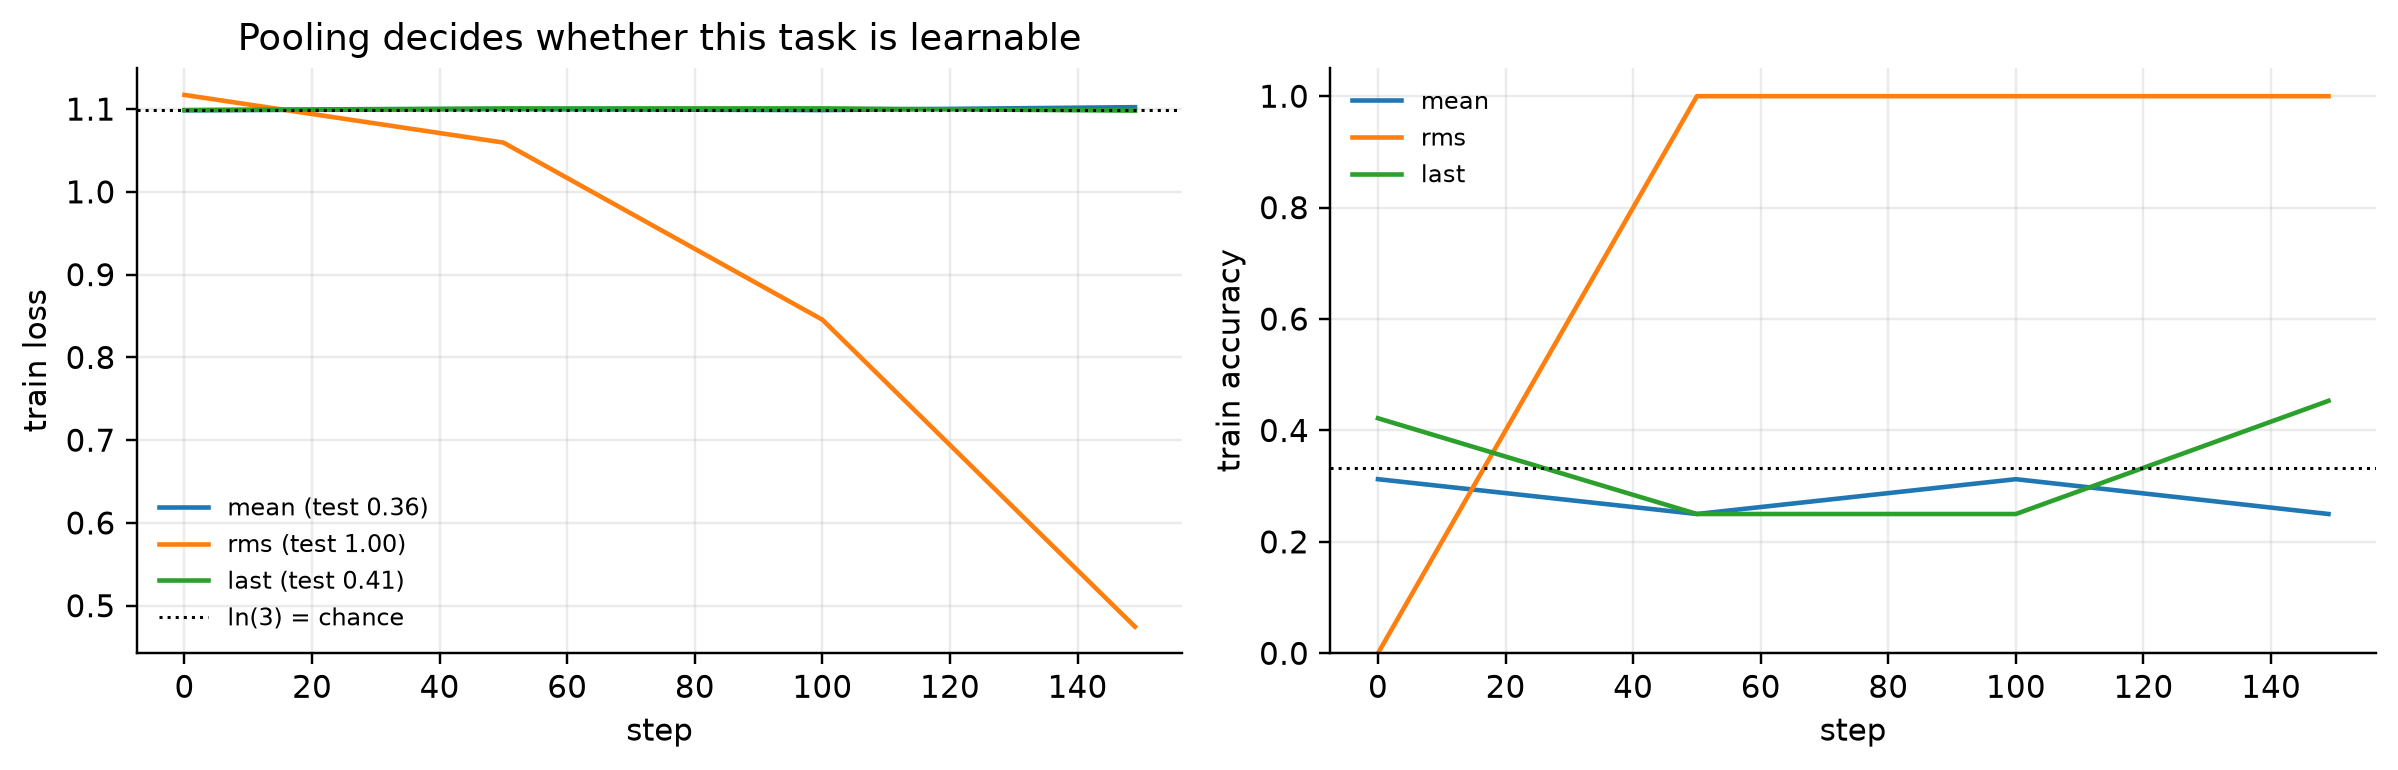

In [ ]:
results = {}
for pool in ["mean", "rms", "last"]:
    print(f"  pool = {pool}")
    p0 = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15, pool=pool)
    p_end, hist = train(p0, freq_batch, DT_F, pool, steps=150, log=True)
    xt, yt = freq_batch(jax.random.PRNGKey(999), 1024)
    acc = float(loss_and_acc(p_end, xt, yt, DT_F, pool)[1])
    results[pool] = (hist, acc)
    print(f"    test acc {acc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for pool, (h, acc) in results.items():
    ax[0].plot(h["step"], h["loss"], label=f"{pool} (test {acc:.2f})")
    ax[1].plot(h["step"], h["acc"], label=pool)
ax[0].axhline(np.log(3), color="k", ls=":", lw=1, label="ln(3) = chance")
ax[0].set(xlabel="step", ylabel="train loss", title="Pooling decides whether this task is learnable")
ax[1].axhline(1/3, color="k", ls=":", lw=1)
ax[1].set(xlabel="step", ylabel="train accuracy", ylim=(0, 1.05))
ax[0].legend(fontsize=8, frameon=False); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. Sequential MNIST, row-wise

28 steps of 28 features. Fast enough to debug against, but note from section 1 that 28 steps give
a usable band ratio of only 2.8 — this task cannot exercise a nested band structure. It is a
correctness check, not the real benchmark.

In [ ]:
from horn.data import load_mnist

# scale="unit" keeps pixels in [0, 1] and therefore keeps the DC component. That
# is deliberate: most of an MNIST image is background, so a constant offset is a
# large part of the drive, and "meanrms" pooling below is what picks it up.
# Compare against scale="standard" if the DC term turns out to dominate.
XTR, YTR, XTE, YTE = load_mnist(DATA_DIR, scale="unit")
print("train", XTR.shape, "test", XTE.shape)
print("pixel range", float(XTR.min()), "to", float(XTR.max()), " mean", float(XTR.mean()))


MNIST not cached, downloading to /home/jesus/horn-jax/data/mnist.npz (~11 MB, once):
  fetching train-images-idx3-ubyte.gz from ossci-datasets.s3.amazonaws.com ...


  fetching train-labels-idx1-ubyte.gz from ossci-datasets.s3.amazonaws.com ...
  fetching t10k-images-idx3-ubyte.gz from ossci-datasets.s3.amazonaws.com ...
  fetching t10k-labels-idx1-ubyte.gz from ossci-datasets.s3.amazonaws.com ...
  cached to /home/jesus/horn-jax/data/mnist.npz
train (60000, 28, 28) test (10000, 28, 28)
pixel range 0.0 to 1.0  mean 0.13066047430038452


In [ ]:
ROW_L, ROW_T = 28, 0.28                 # 28 rows spanning 0.28 s
ROW_DT = ROW_T / ROW_L
ROW_LO, ROW_HI = usable_band(ROW_L, ROW_DT)
print(f"row-wise: dt={ROW_DT*1000:.1f} ms, usable band {ROW_LO:.1f}-{ROW_HI:.1f} Hz")

XTR_ROW = jnp.asarray(XTR.transpose(1, 0, 2))       # (28 rows, N, 28 cols)
XTE_ROW = jnp.asarray(XTE.transpose(1, 0, 2))
YTR_J, YTE_J = jnp.asarray(YTR), jnp.asarray(YTE)

def row_batch(key, n):
    idx = jax.random.randint(key, (n,), 0, XTR_ROW.shape[1])
    return XTR_ROW[:, idx, :], YTR_J[idx]

def evaluate(params, X, Y, dt, pool, chunk=500):
    accs = []
    for i in range(0, X.shape[1], chunk):
        accs.append(float(loss_and_acc(params, X[:, i:i+chunk], Y[i:i+chunk], dt, pool)[1])
                    * X[:, i:i+chunk].shape[1])
    return sum(accs) / X.shape[1]

N_OSC_M, POOL_M = 96, "meanrms"
p0_row = init_net(jax.random.PRNGKey(0), 28, N_OSC_M, 10,
                  f_hz=log_spaced_bands(N_OSC_M, ROW_LO, ROW_HI), zeta=0.15, pool=POOL_M)
p_row, h_row = train(p0_row, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, lr=3e-3)
print(f"  row-wise sMNIST test accuracy: {evaluate(p_row, XTE_ROW, YTE_J, ROW_DT, POOL_M):.4f}")

row-wise: dt=10.0 ms, usable band 3.6-10.0 Hz
    step     0  loss 2.3055  acc 0.109  |g| 1.15e-01
    step   200  loss 1.2462  acc 0.641  |g| 2.87e-01
    step   400  loss 0.7694  acc 0.805  |g| 1.64e-01
    step   600  loss 0.6674  acc 0.844  |g| 1.58e-01
    step   800  loss 0.5221  acc 0.867  |g| 1.61e-01
    step  1000  loss 0.4418  acc 0.930  |g| 1.65e-01
    step  1200  loss 0.4471  acc 0.859  |g| 2.30e-01
    step  1400  loss 0.4249  acc 0.891  |g| 2.42e-01
    step  1499  loss 0.4709  acc 0.867  |g| 2.16e-01
    [28.1s]
  row-wise sMNIST test accuracy: 0.8971


## 6. Frozen vs learned $(\omega, \zeta)$

Notebook 01 argued that gradient descent through oscillatory dynamics is unlikely to move
$\omega$ and $\zeta$ far, so whatever range of timescales a task needs must be reachable from the
initialisation. This tests it directly: identical architecture and initialisation, one run with
the oscillator constants frozen and one with them free.

If the frozen run matches the learned run, then the bank is doing its work through
$W_{in}$/$W_{rec}$/readout and the oscillator constants are effectively hyperparameters, not
parameters. That would make **initialisation the design decision**, which is exactly the claim.

  frozen omega/zeta:
    step     0  loss 2.3055  acc 0.109  |g| 1.15e-01
    step   200  loss 1.7645  acc 0.641  |g| 1.88e-01
    step   400  loss 1.3335  acc 0.766  |g| 1.35e-01
    step   600  loss 1.1254  acc 0.812  |g| 8.54e-02
    step   800  loss 0.9238  acc 0.812  |g| 7.55e-02
    step  1000  loss 0.7467  acc 0.875  |g| 6.01e-02
    step  1200  loss 0.7367  acc 0.820  |g| 9.15e-02
    step  1400  loss 0.6708  acc 0.812  |g| 8.36e-02
    step  1499  loss 0.6409  acc 0.867  |g| 7.48e-02
    [17.9s]
  learned omega/zeta:
    step     0  loss 2.3055  acc 0.109  |g| 1.15e-01
    step   200  loss 1.2462  acc 0.641  |g| 2.87e-01
    step   400  loss 0.7694  acc 0.805  |g| 1.64e-01
    step   600  loss 0.6674  acc 0.844  |g| 1.58e-01
    step   800  loss 0.5221  acc 0.867  |g| 1.61e-01
    step  1000  loss 0.4418  acc 0.930  |g| 1.65e-01
    step  1200  loss 0.4471  acc 0.859  |g| 2.30e-01
    step  1400  loss 0.4249  acc 0.891  |g| 2.42e-01
    step  1499  loss 0.4709  acc 0.867  |g| 

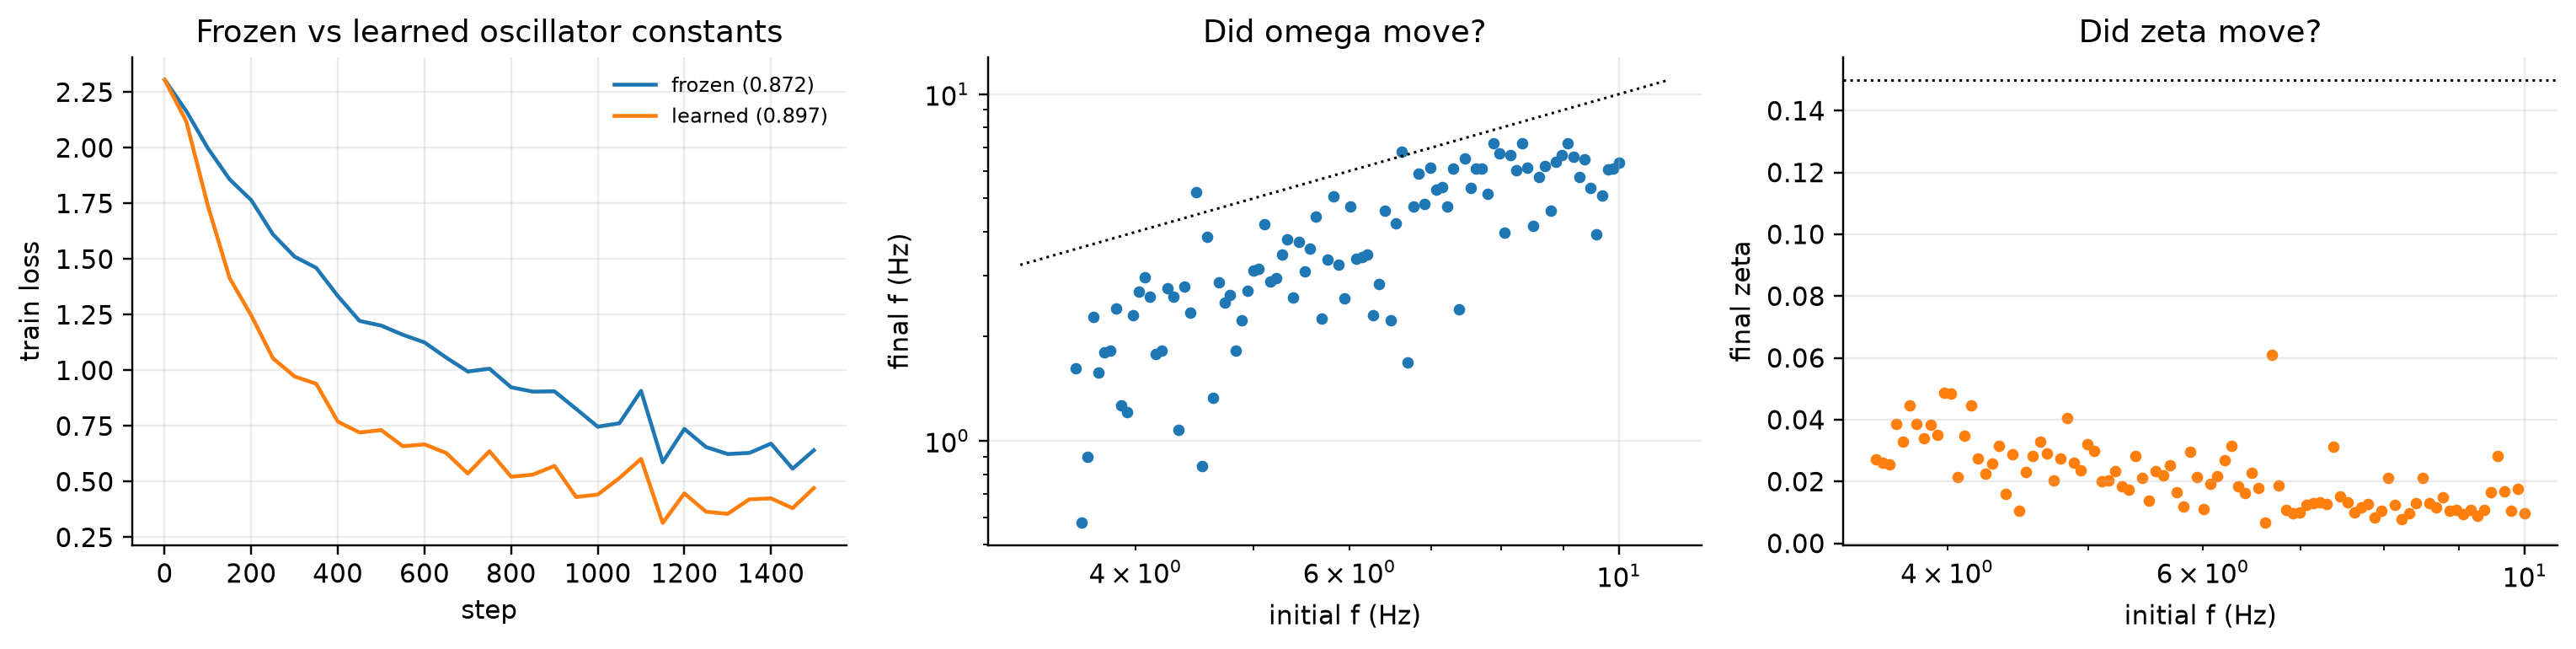

In [ ]:
p0 = init_net(jax.random.PRNGKey(0), 28, N_OSC_M, 10,
              f_hz=log_spaced_bands(N_OSC_M, ROW_LO, ROW_HI), zeta=0.15, pool=POOL_M)

print("  frozen omega/zeta:")
p_frozen, h_frozen = train(p0, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, freeze=True)
acc_frozen = evaluate(p_frozen, XTE_ROW, YTE_J, ROW_DT, POOL_M)

print("  learned omega/zeta:")
p_learned, h_learned = train(p0, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, freeze=False)
acc_learned = evaluate(p_learned, XTE_ROW, YTE_J, ROW_DT, POOL_M)

print(f"\n  frozen  test acc {acc_frozen:.4f}")
print(f"  learned test acc {acc_learned:.4f}   (difference {acc_learned - acc_frozen:+.4f})")

s0, sl = band_summary(p0), band_summary(p_learned)
rel = jnp.abs(sl["f_hz"] - s0["f_hz"]) / s0["f_hz"]
print(f"\n  how far did the bank actually move?")
print(f"    f_hz : {float(s0['f_hz'].min()):.2f}-{float(s0['f_hz'].max()):.2f}"
      f"  ->  {float(sl['f_hz'].min()):.2f}-{float(sl['f_hz'].max()):.2f} Hz")
print(f"    median |df|/f = {float(jnp.median(rel))*100:.1f}%,  max = {float(rel.max())*100:.1f}%")
print(f"    zeta : {float(s0['zeta'][0]):.3f}  ->  {float(sl['zeta'].min()):.3f}-{float(sl['zeta'].max()):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(h_frozen["step"], h_frozen["loss"], label=f"frozen ({acc_frozen:.3f})")
ax[0].plot(h_learned["step"], h_learned["loss"], label=f"learned ({acc_learned:.3f})")
ax[0].set(xlabel="step", ylabel="train loss", title="Frozen vs learned oscillator constants")
ax[0].legend(fontsize=8, frameon=False)
ax[1].scatter(np.asarray(s0["f_hz"]), np.asarray(sl["f_hz"]), s=12, color="C0")
lim = [float(s0["f_hz"].min()) * 0.9, float(s0["f_hz"].max()) * 1.1]
ax[1].plot(lim, lim, "k:", lw=1)
ax[1].set(xlabel="initial f (Hz)", ylabel="final f (Hz)", title="Did omega move?", xscale="log", yscale="log")
ax[2].scatter(np.asarray(s0["f_hz"]), np.asarray(sl["zeta"]), s=12, color="C1")
ax[2].axhline(0.15, color="k", ls=":", lw=1)
ax[2].set(xlabel="initial f (Hz)", ylabel="final zeta", title="Did zeta move?", xscale="log")
plt.tight_layout(); plt.show()

## 7. Sequential MNIST, pixel-wise

784 steps of one feature — the standard benchmark, and the one published HORN numbers use.
BPTT memory is 28x the row-wise case, so expect this to be substantially slower.

This is also the first setting where the band structure has room: 784 steps give a usable ratio
of ~78, so theta through gamma all fit and a nested architecture becomes representable.

In [ ]:
PIX_L, PIX_T = 784, 1.0
PIX_DT = PIX_T / PIX_L
PIX_LO, PIX_HI = usable_band(PIX_L, PIX_DT)
print(f"pixel-wise: dt={PIX_DT*1000:.3f} ms, usable band {PIX_LO:.1f}-{PIX_HI:.1f} Hz "
      f"(ratio {PIX_HI/PIX_LO:.0f}) -> a 1:6 nesting fits comfortably")

XTR_PIX = jnp.asarray(XTR.reshape(XTR.shape[0], -1).T[:, :, None])   # (784, N, 1)
XTE_PIX = jnp.asarray(XTE.reshape(XTE.shape[0], -1).T[:, :, None])

def pix_batch(key, n):
    idx = jax.random.randint(key, (n,), 0, XTR_PIX.shape[1])
    return XTR_PIX[:, idx, :], YTR_J[idx]

RUN_PIXELWISE = True        # set True when you have time; this is the slow one

if RUN_PIXELWISE:
    N_OSC_P = 128
    p0_pix = init_net(jax.random.PRNGKey(0), 1, N_OSC_P, 10,
                      f_hz=log_spaced_bands(N_OSC_P, PIX_LO, PIX_HI), zeta=0.15, pool=POOL_M)
    p_pix, h_pix = train(p0_pix, pix_batch, PIX_DT, POOL_M, steps=3000, batch=64, lr=1e-3)
    print(f"  pixel-wise sMNIST test accuracy: {evaluate(p_pix, XTE_PIX, YTE_J, PIX_DT, POOL_M):.4f}")
else:
    print("RUN_PIXELWISE = False -- skipped.")

pixel-wise: dt=1.276 ms, usable band 1.0-78.4 Hz (ratio 78) -> a 1:6 nesting fits comfortably
    step     0  loss 2.3026  acc 0.062  |g| 7.89e-02
    step   200  loss 2.2804  acc 0.109  |g| 2.09e-01
    step   400  loss 2.2420  acc 0.188  |g| 2.05e-01
    step   600  loss 1.9652  acc 0.578  |g| 2.16e-01
    step   800  loss 1.3312  acc 0.641  |g| 3.12e-01
    step  1000  loss 0.8831  acc 0.766  |g| 3.30e-01
    step  1200  loss 1.0433  acc 0.656  |g| 6.50e-01
    step  1400  loss 0.7630  acc 0.781  |g| 2.88e-01
    step  1600  loss 0.8235  acc 0.688  |g| 4.55e-01
    step  1800  loss 0.8194  acc 0.703  |g| 5.30e-01
    step  2000  loss 0.6280  acc 0.812  |g| 5.20e-01
    step  2200  loss 0.6088  acc 0.797  |g| 4.83e-01
    step  2400  loss 0.8457  acc 0.734  |g| 7.18e-01
    step  2600  loss 0.6460  acc 0.812  |g| 4.24e-01
    step  2800  loss 0.8398  acc 0.672  |g| 7.50e-01
    step  2999  loss 0.7163  acc 0.766  |g| 9.56e-01
    [1307.3s]
  pixel-wise sMNIST test accuracy: 0.7935


## Conclusion

**What had to be fixed before anything trained**, both predicted by notebook 01:

1. `W_in` scaled by $2\zeta\omega^2$. Without it the population output is $\sim10^{-6}$, the loss sits
   exactly at $\ln(n_{classes})$, and gradients are ~$10^{-4}$. This is finding #2 from notebook 01
   appearing at initialisation rather than in analysis.
2. Power pooling rather than mean pooling for oscillatory responses. The mean/rms ratio falls
   with frequency, so mean-pooling discards most from the units working hardest.

**Carried forward:**

- The usable frequency ratio is $L/10$, set by sequence length alone. Row-wise MNIST (28 steps,
  ratio 2.8) cannot represent a 1:6 nesting; pixel-wise (784 steps, ratio 78) can. **The nested
  experiment needs a long-sequence task**, which rules out several convenient benchmarks.
- $(x, v/\omega)$ rather than $(x, v)$ at the readout, or velocity dominates by a factor of $\omega$.

**Next:**

- Stack layers, and check whether depth or width is the better use of parameters here.
- Banded $\omega$ with cross-frequency amplitude modulation, against flat heterogeneity at
  matched parameter count — the actual research question, on a long-sequence task.
- A spiking readout, and whether phase coding degrades more gracefully than a continuous readout
  under quantisation of the hidden state.
